In [1]:
# ============================================================
# 07_feature_enrichment.ipynb
# Wellmatch Workforce Analytics — UCL Dissertation 2026
# Feature enrichment: EWCS benchmarking + occupation gap +
#                     per-employee cost layer
# Architecture: Option 2 (benchmark feature) + per-employee cost
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

PROJECT_ROOT = Path.cwd().parent
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
OUTPUTS      = PROJECT_ROOT / "outputs"
OUTPUTS_FIG  = OUTPUTS / "figures"
OUTPUTS_TAB  = OUTPUTS / "tables"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)

IBM_PATH = DATA_RAW / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
print("IBM file exists:", IBM_PATH.exists())
print("Project root:", PROJECT_ROOT)

IBM file exists: True
Project root: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd


In [2]:
# Load raw IBM data
df = pd.read_csv(IBM_PATH)
print(f"Raw shape: {df.shape}")

# Drop zero-variance columns ONLY (keep EmployeeNumber as an ID,
# keep all categoricals readable — no one-hot encoding in this notebook)
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

# Encode target to match baseline (Yes->1, No->0)
df['Attrition_flag'] = (df['Attrition'] == 'Yes').astype(int)

# Rebuild WellbeingIndex EXACTLY as in notebook 05 (locked decision)
wellbeing_vars = ['JobSatisfaction', 'EnvironmentSatisfaction',
                  'RelationshipSatisfaction', 'WorkLifeBalance']
df['WellbeingIndex'] = df[wellbeing_vars].mean(axis=1)

print(f"Clean shape: {df.shape}")
print(f"Attrition rate: {df['Attrition_flag'].mean():.3f}")
print(f"WellbeingIndex mean: {df['WellbeingIndex'].mean():.3f} "
      f"(corr with attrition: {df['WellbeingIndex'].corr(df['Attrition_flag']):.3f})")
df[['EmployeeNumber', 'JobRole', 'MonthlyIncome',
    'WellbeingIndex', 'Attrition']].head()

Raw shape: (1470, 35)
Clean shape: (1470, 34)
Attrition rate: 0.161
WellbeingIndex mean: 2.731 (corr with attrition: -0.159)


,EmployeeNumber,JobRole,MonthlyIncome,WellbeingIndex,Attrition
0,1,Sales Executive,5993,2.00,Yes
1,2,Research Scientist,5130,3.00,No
2,4,Laboratory Technician,2090,3.00,Yes
3,5,Research Scientist,2909,3.25,No
4,7,Laboratory Technician,3468,2.50,No


In [3]:
# Provenance register: tag every column with its data source.
# This is what enforces the "never mix synthetic/derived/external
# silently" rule — we update it as we add each new feature.
provenance = {col: "IBM_synthetic_benchmark" for col in df.columns}

# The two we just engineered are derived, not original IBM fields
provenance['Attrition_flag']  = "derived_from_IBM"
provenance['WellbeingIndex']  = "derived_from_IBM"

print(f"Columns tracked: {len(provenance)}")
print("\nSample of provenance register:")
for k in ['Age', 'JobRole', 'MonthlyIncome', 'WellbeingIndex', 'Attrition_flag']:
    print(f"  {k:20s} -> {provenance[k]}")

Columns tracked: 34

Sample of provenance register:
  Age                  -> IBM_synthetic_benchmark
  JobRole              -> IBM_synthetic_benchmark
  MonthlyIncome        -> IBM_synthetic_benchmark
  WellbeingIndex       -> derived_from_IBM
  Attrition_flag       -> derived_from_IBM


In [4]:
EWCS_DRIVERS_PATH = OUTPUTS_TAB / "ewcs_atrisk_comparison.csv"
print("EWCS drivers file exists:", EWCS_DRIVERS_PATH.exists())

ewcs_drivers = pd.read_csv(EWCS_DRIVERS_PATH)
print(f"EWCS driver rows: {len(ewcs_drivers)}")

# Top 8 EWCS drivers of intent-to-leave by absolute effect size
ewcs_top = ewcs_drivers.sort_values('abs_d', ascending=False).head(8)
print("\nTop EWCS drivers of intent-to-leave (Cohen's d):")
print(ewcs_top[['group', 'variable', 'cohens_d', 'abs_d']].to_string(index=False))

EWCS drivers file exists: True
EWCS driver rows: 44

Top EWCS drivers of intent-to-leave (Cohen's d):
               group            variable  cohens_d  abs_d
recognition_security         recognition     0.520  0.520
  wellbeing_outcomes    eng_enthusiastic     0.512  0.512
      stress_culture priority_well_being     0.472  0.472
  wellbeing_outcomes          eng_energy     0.456  0.456
      stress_culture      fair_treatment     0.431  0.431
      stress_culture       work_welldone     0.424  0.424
      stress_culture         useful_work     0.404  0.404
  wellbeing_outcomes        exhaust_emot    -0.386  0.386


In [5]:
# IBM wellbeing/satisfaction drivers vs attrition (higher score = better,
# so negative corr = protective against leaving)
ibm_driver_vars = ['WellbeingIndex', 'JobSatisfaction', 'EnvironmentSatisfaction',
                   'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

ibm_drivers = (df[ibm_driver_vars + ['Attrition_flag']]
               .corr()['Attrition_flag']
               .drop('Attrition_flag')
               .rename('corr_with_attrition')
               .reset_index()
               .rename(columns={'index': 'variable'}))
ibm_drivers['abs_corr'] = ibm_drivers['corr_with_attrition'].abs()
ibm_drivers = ibm_drivers.sort_values('abs_corr', ascending=False)

print("IBM drivers of attrition (correlation):")
print(ibm_drivers.to_string(index=False))

# OverTime reported SEPARATELY — endogenous, correlation only (locked rule D)
ot_corr = (df['OverTime'] == 'Yes').astype(int).corr(df['Attrition_flag'])
print(f"\n[Endogenous — reported as correlation only] "
      f"OverTime vs Attrition: {ot_corr:.3f}")

IBM drivers of attrition (correlation):
                variable  corr_with_attrition  abs_corr
          WellbeingIndex            -0.159092  0.159092
          JobInvolvement            -0.130016  0.130016
         JobSatisfaction            -0.103481  0.103481
 EnvironmentSatisfaction            -0.103369  0.103369
         WorkLifeBalance            -0.063939  0.063939
RelationshipSatisfaction            -0.045872  0.045872

[Endogenous — reported as correlation only] OverTime vs Attrition: 0.246


In [6]:
# Conceptual crosswalk: match each theme to its closest EWCS and IBM measure.
# This is a CONCEPTUAL alignment, not a statistical equivalence.
theme_map = {
    'Wellbeing / affect':           ('wellbeing',         'WellbeingIndex'),
    'Recognition / environment':    ('recognition',       'EnvironmentSatisfaction'),
    'Engagement / enthusiasm':      ('eng_enthusiastic',  'JobInvolvement'),
    'Relational / manager support': ('support_manager',   'RelationshipSatisfaction'),
    'Work-life balance':            ('work_life_balance', 'WorkLifeBalance'),
    'Job satisfaction':             ('useful_work',       'JobSatisfaction'),
}

rows = []
ewcs_lookup = ewcs_drivers.set_index('variable')
ibm_lookup  = ibm_drivers.set_index('variable')
for theme, (ev, iv) in theme_map.items():
    rows.append({
        'Theme': theme,
        'EWCS measure': ev,
        "EWCS |d|": round(abs(ewcs_lookup.loc[ev, 'cohens_d']), 3) if ev in ewcs_lookup.index else np.nan,
        'IBM measure': iv,
        'IBM |corr|': round(abs(ibm_lookup.loc[iv, 'corr_with_attrition']), 3) if iv in ibm_lookup.index else np.nan,
    })
convergence = pd.DataFrame(rows)
convergence.to_csv(OUTPUTS_TAB / "convergent_validity_ewcs_vs_ibm.csv", index=False)
print("CONVERGENT VALIDITY: EWCS vs IBM — same themes drive leaving in both datasets\n")
print(convergence.to_string(index=False))

CONVERGENT VALIDITY: EWCS vs IBM — same themes drive leaving in both datasets

                       Theme      EWCS measure  EWCS |d|              IBM measure  IBM |corr|
          Wellbeing / affect         wellbeing     0.373           WellbeingIndex       0.159
   Recognition / environment       recognition     0.520  EnvironmentSatisfaction       0.103
     Engagement / enthusiasm  eng_enthusiastic     0.512           JobInvolvement       0.130
Relational / manager support   support_manager     0.351 RelationshipSatisfaction       0.046
           Work-life balance work_life_balance     0.285          WorkLifeBalance       0.064
            Job satisfaction       useful_work     0.404          JobSatisfaction       0.103


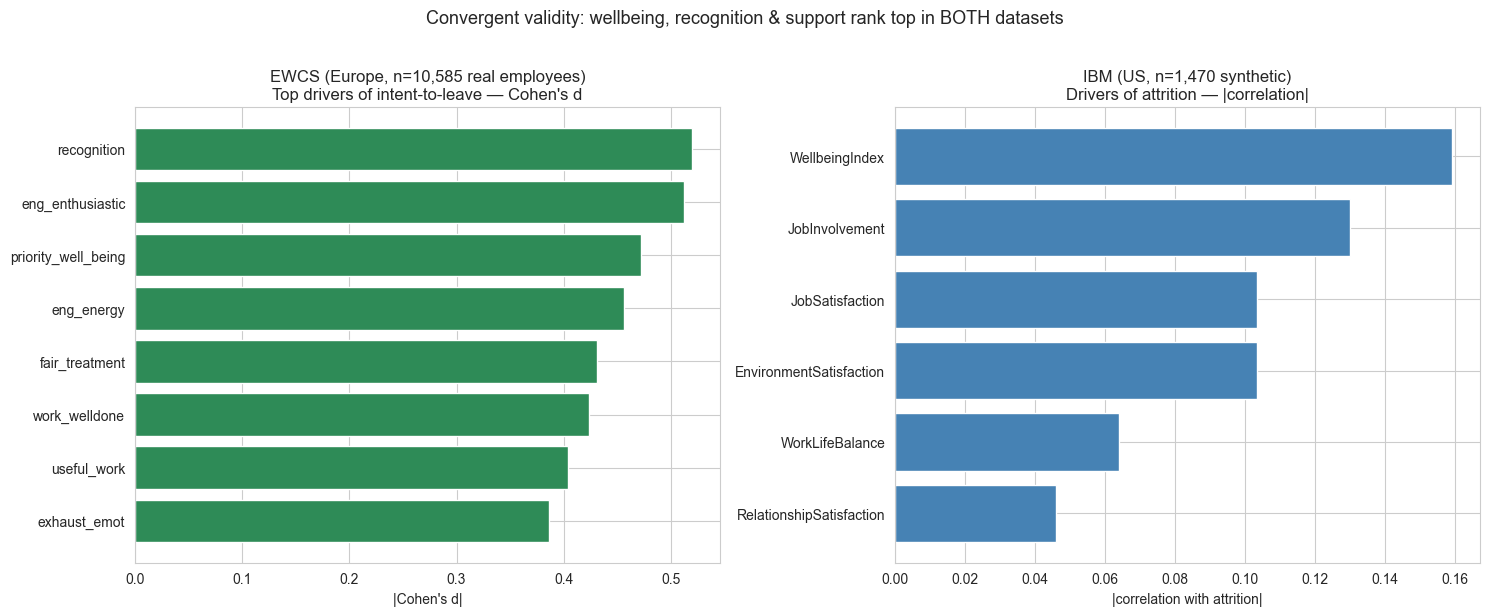

Saved: outputs/figures/convergent_validity_ewcs_vs_ibm.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: EWCS top drivers (Cohen's d)
e = ewcs_top.iloc[::-1]
axes[0].barh(e['variable'], e['abs_d'], color='seagreen')
axes[0].set_title("EWCS (Europe, n=10,585 real employees)\nTop drivers of intent-to-leave — Cohen's d")
axes[0].set_xlabel("|Cohen's d|")

# Right: IBM drivers (|correlation|)
i = ibm_drivers.iloc[::-1]
axes[1].barh(i['variable'], i['abs_corr'], color='steelblue')
axes[1].set_title("IBM (US, n=1,470 synthetic)\nDrivers of attrition — |correlation|")
axes[1].set_xlabel("|correlation with attrition|")

fig.suptitle("Convergent validity: wellbeing, recognition & support rank top in BOTH datasets",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_FIG / "convergent_validity_ewcs_vs_ibm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/convergent_validity_ewcs_vs_ibm.png")

In [8]:
import pyreadstat

DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"
EWCS_PATH = DATA_EXTERNAL / "UKDA-9511-stata" / "stata" / "stata13" / "ewcs24_dataset_ukds.dta"
print("EWCS exists:", EWCS_PATH.exists())

# Metadata only — fast, no data load
_, meta = pyreadstat.read_dta(str(EWCS_PATH), metadataonly=True)

# Find occupation-related variables by name OR label
cands = []
for name, label in zip(meta.column_names, meta.column_labels):
    text = f"{name} {str(label)}".lower()
    if any(k in text for k in ['isco', 'occupation', 'occup', 'job categ', 'ept', 'skill level']):
        cands.append((name, label))

print(f"\nCandidate occupation variables ({len(cands)}):")
for name, label in cands:
    print(f"  {name:22s} | {label}")

# Print value labels for any candidate that has them (this gives us the categories)
for name, label in cands:
    if name in meta.variable_value_labels:
        print(f"\n=== {name}: {label} ===")
        for k, v in sorted(meta.variable_value_labels[name].items()):
            if k >= 0:   # skip missing codes
                print(f"  {int(k)}: {v}")

EWCS exists: True

Candidate occupation variables (6):
  ISCO_2                 | ISCO_2
  ISCO_1                 | ISCO_1
  wlb_worry              | kept worrying about work when you were not working
  reptasks_1minute       | Please tell me whether your job involves short repetitive tasks lasting less tha
  reptasks_10minute      | Please tell me whether your job involves short repetitive tasks lasting less tha
  occupation             | Variable used for weighting: occupation. N.B. occupations 3 & 0 and 6 & 7 are co

=== ISCO_2: ISCO_2 ===
  1: Commissioned armed forces officers
  2: Non-commissioned armed forces officers
  3: Armed forces occupations, other ranks
  11: Chief executives, senior officials and legislators
  12: Administrative and commercial managers
  13: Production and specialised services managers
  14: Hospitality, retail and other services managers
  21: Science and engineering professionals
  22: Health professionals
  23: Teaching professionals
  24: Business an

In [9]:
print("IBM JobRole categories to map:\n")
print(df['JobRole'].value_counts())

IBM JobRole categories to map:

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


In [10]:
target_country_codes = {2:'Belgium',7:'Denmark',9:'Finland',10:'France',11:'Germany',
                        14:'Ireland',18:'Luxembourg',20:'Netherlands',21:'Norway',
                        28:'Sweden',29:'Switzerland'}

cols_needed = ['country','employee_selfdeclared','wellbeing','ISCO_1','ISCO_2','calweight']
ewcs, _ = pyreadstat.read_dta(str(EWCS_PATH), usecols=cols_needed)

# Replicate notebook 02 filters: target countries, employees only, missing codes -> NaN
ewcs = ewcs[ewcs['country'].isin(target_country_codes)].copy()
ewcs = ewcs[ewcs['employee_selfdeclared'] == 1].copy()
for c in ['wellbeing','ISCO_1','ISCO_2']:
    ewcs[c] = ewcs[c].mask(ewcs[c].isin([-999,-998,-991,-555,995]))

# Weighted mean WHO-5 wellbeing per ISCO-2 occupation (apply survey weight calweight)
def wmean(g):
    s = g.dropna(subset=['wellbeing','calweight'])
    return np.average(s['wellbeing'], weights=s['calweight']) if len(s) else np.nan

occ = (ewcs.dropna(subset=['ISCO_2'])
          .groupby('ISCO_2')
          .apply(lambda g: pd.Series({'ewcs_wellbeing': wmean(g),
                                       'n': int(g['wellbeing'].notna().sum())}))
          .reset_index())
occ['ISCO_2'] = occ['ISCO_2'].astype(int)
occ_stable = occ[occ['n'] >= 30].sort_values('ewcs_wellbeing')
print(f"ISCO-2 groups total: {len(occ)} | with n>=30: {len(occ_stable)}\n")
print("EWCS WHO-5 wellbeing by ISCO-2 occupation (weighted, n>=30, low to high):")
print(occ_stable.to_string(index=False))

ISCO-2 groups total: 43 | with n>=30: 36

EWCS WHO-5 wellbeing by ISCO-2 occupation (weighted, n>=30, low to high):
 ISCO_2  ewcs_wellbeing     n
     42       64.224878 184.0
     92       64.430342  41.0
     32       64.682251 320.0
     23       64.688211 902.0
     83       64.864893 331.0
     91       65.248133 271.0
     26       65.601587 357.0
     35       65.730712 101.0
     93       65.741020 192.0
     33       66.198300 689.0
     43       66.298743 276.0
     82       66.354365  50.0
     75       66.555236 100.0
     53       67.535554 642.0
     22       67.847289 455.0
     74       68.345775 147.0
     25       68.425406 365.0
     31       68.612466 384.0
     34       69.138631 305.0
     52       69.222885 583.0
     41       69.336933 314.0
     24       69.357344 567.0
     21       69.406934 395.0
     44       69.438522 109.0
     14       69.456014  76.0
     96       69.735374  89.0
     94       69.887557  84.0
     11       70.098092 103.0
     51       

In [11]:
# Documented crosswalk: IBM JobRole -> ISCO-2 occupation (APPROXIMATE benchmark, not a validated linkage)
jobrole_to_isco2 = {
    'Research Scientist':        21,
    'Research Director':         21,   # seniority caveat: mapped to field, not management
    'Laboratory Technician':     31,
    'Manufacturing Director':    13,
    'Manager':                   12,
    'Healthcare Representative': 32,
    'Sales Executive':           52,
    'Sales Representative':      52,
    'Human Resources':           24,
}
isco2_label = {21:'Science & engineering professionals', 31:'Science & engineering assoc. professionals',
               13:'Production & specialised services managers', 12:'Administrative & commercial managers',
               32:'Health associate professionals', 52:'Sales workers', 24:'Business & admin professionals'}

occ_map = occ.set_index('ISCO_2')['ewcs_wellbeing'].to_dict()

df['ISCO2_code']        = df['JobRole'].map(jobrole_to_isco2)
df['ISCO2_label']       = df['ISCO2_code'].map(isco2_label)
df['EWCS_OccWellbeing'] = df['ISCO2_code'].map(occ_map)      # external WHO-5 benchmark (0-100), context only

# Within-IBM, SAME-construct gap vs same-role peers — the engineered feature
df['RoleMeanWellbeing']   = df.groupby('JobRole')['WellbeingIndex'].transform('mean')
df['WellbeingGap_vsRole'] = df['WellbeingIndex'] - df['RoleMeanWellbeing']

# Provenance
provenance['ISCO2_code']          = "crosswalk_IBM_to_EWCS"
provenance['ISCO2_label']         = "crosswalk_IBM_to_EWCS"
provenance['EWCS_OccWellbeing']   = "EWCS_external_benchmark"
provenance['RoleMeanWellbeing']   = "derived_from_IBM"
provenance['WellbeingGap_vsRole'] = "derived_from_IBM"

print("Sample of attached features:")
print(df[['JobRole','ISCO2_label','EWCS_OccWellbeing','WellbeingIndex',
          'RoleMeanWellbeing','WellbeingGap_vsRole']].head(8).to_string(index=False))
print(f"\nWellbeingGap_vsRole: mean={df['WellbeingGap_vsRole'].mean():.4f} (≈0 by construction), "
      f"std={df['WellbeingGap_vsRole'].std():.3f}, "
      f"range=[{df['WellbeingGap_vsRole'].min():.2f}, {df['WellbeingGap_vsRole'].max():.2f}]")

Sample of attached features:
              JobRole                                ISCO2_label  EWCS_OccWellbeing  WellbeingIndex  RoleMeanWellbeing  WellbeingGap_vsRole
      Sales Executive                              Sales workers          69.222885            2.00           2.733129            -0.733129
   Research Scientist        Science & engineering professionals          69.406934            3.00           2.720890             0.279110
Laboratory Technician Science & engineering assoc. professionals          68.612466            3.00           2.703668             0.296332
   Research Scientist        Science & engineering professionals          69.406934            3.25           2.720890             0.529110
Laboratory Technician Science & engineering assoc. professionals          68.612466            2.50           2.703668            -0.203668
Laboratory Technician Science & engineering assoc. professionals          68.612466            3.25           2.703668             

In [12]:
role_validation = (df.groupby(['JobRole','ISCO2_label'])
                     .agg(IBM_role_wellbeing=('WellbeingIndex','mean'),
                          EWCS_occ_wellbeing=('EWCS_OccWellbeing','first'),
                          attrition_rate=('Attrition_flag','mean'),
                          n=('WellbeingIndex','size'))
                     .reset_index()
                     .sort_values('EWCS_occ_wellbeing'))
print("Role-level external validation (IBM internal vs EWCS external wellbeing):")
print(role_validation.round(3).to_string(index=False))

# Cross-role correlation — n=9, DESCRIPTIVE ONLY (not significance-tested)
r = role_validation['IBM_role_wellbeing'].corr(role_validation['EWCS_occ_wellbeing'])
print(f"\nCross-role corr (IBM vs EWCS wellbeing): r = {r:.3f}  "
      f"[n={len(role_validation)} roles — descriptive only]")
role_validation.to_csv(OUTPUTS_TAB / "role_external_validation.csv", index=False)

Role-level external validation (IBM internal vs EWCS external wellbeing):
                  JobRole                                ISCO2_label  IBM_role_wellbeing  EWCS_occ_wellbeing  attrition_rate   n
Healthcare Representative             Health associate professionals               2.739              64.682           0.069 131
    Laboratory Technician Science & engineering assoc. professionals               2.704              68.612           0.239 259
          Sales Executive                              Sales workers               2.733              69.223           0.175 326
     Sales Representative                              Sales workers               2.741              69.223           0.398  83
          Human Resources             Business & admin professionals               2.760              69.357           0.231  52
        Research Director        Science & engineering professionals               2.688              69.407           0.025  80
       Research Scienti

In [13]:
# ============================================================
# Section 4 — ROI parameter table (documented constants)
# Each constant carries a source + data_source tag. Single source
# of truth feeding the cost layer (Sec 5) and notebook 08.
# ============================================================

# Replacement-cost multiplier (share of ANNUAL salary) by JobLevel.
# Senior roles cost more to replace (recruitment + longer ramp-up +
# lost output). Range anchored to SHRM (~0.5x-2x salary) and
# Oxford Economics (2014) UK avg turnover cost (~£30k/employee).
REPLACEMENT_MULTIPLIER = {1: 0.50, 2: 0.75, 3: 1.00, 4: 1.50, 5: 2.00}

PARAMS = [
 ('replacement_multiplier_L1', 0.50, 'x annual salary', 'SHRM / Oxford Economics 2014', 'literature'),
 ('replacement_multiplier_L2', 0.75, 'x annual salary', 'SHRM / Oxford Economics 2014', 'literature'),
 ('replacement_multiplier_L3', 1.00, 'x annual salary', 'SHRM / Oxford Economics 2014', 'literature'),
 ('replacement_multiplier_L4', 1.50, 'x annual salary', 'SHRM / Oxford Economics 2014', 'literature'),
 ('replacement_multiplier_L5', 2.00, 'x annual salary', 'SHRM / Oxford Economics 2014', 'literature'),
 ('uk_working_days_per_year',   226,  'days',            'ONS standard working year',   'ONS'),
 ('uk_absence_days_per_worker', 4.4,  'days/year',       'ONS Sickness Absence 2025 Table 3 — VERIFY FROM NB03', 'ONS'),
 ('uk_mh_share_of_absence',     0.08, 'proportion',      'ONS Table 4a mental-health reason — VERIFY FROM NB03', 'ONS'),
 ('us_absence_rate_pct',        3.2,  '% of days',       'BLS CPS 2024 (NB04)',         'BLS'),
 ('us_working_days_per_year',   240,  'days',            'NB04',                        'BLS'),
 ('wellbeing_roi_ratio',        4.7,  '£ per £1',        'Deloitte 2024 UK Mental Health', 'literature'),
 ('proactive_roi_ratio',        4.2,  '£ per £1',        'Deloitte 2024 (preventative)',   'literature'),
 ('uk_employer_mh_cost_total',  51e9, '£/year',          'Deloitte 2024 (£51bn)',       'literature'),
 ('uk_mh_absence_cost',         7.3e9,'£/year',          'Deloitte 2024',               'literature'),
 ('uk_mh_turnover_cost',        19.5e9,'£/year',         'Deloitte 2024',               'literature'),
 ('pmi_claim_cost_per_head',    600,  '£/employee/year', 'PMI industry proxy — ASSUMPTION, refine', 'assumption'),
]
params_df = pd.DataFrame(PARAMS, columns=['parameter','value','unit','source','data_source'])
params_df.to_csv(OUTPUTS_TAB / 'roi_parameters.csv', index=False)
print("ROI parameter table (feeds cost layer + notebook 08):\n")
print(params_df.to_string(index=False))
print("\n⚠️  Two rows flagged VERIFY — replace with your own notebook 03 figures before treating £ outputs as final.")

ROI parameter table (feeds cost layer + notebook 08):

                 parameter        value            unit                                               source data_source
 replacement_multiplier_L1 5.000000e-01 x annual salary                         SHRM / Oxford Economics 2014  literature
 replacement_multiplier_L2 7.500000e-01 x annual salary                         SHRM / Oxford Economics 2014  literature
 replacement_multiplier_L3 1.000000e+00 x annual salary                         SHRM / Oxford Economics 2014  literature
 replacement_multiplier_L4 1.500000e+00 x annual salary                         SHRM / Oxford Economics 2014  literature
 replacement_multiplier_L5 2.000000e+00 x annual salary                         SHRM / Oxford Economics 2014  literature
  uk_working_days_per_year 2.260000e+02            days                            ONS standard working year         ONS
uk_absence_days_per_worker 4.400000e+00       days/year ONS Sickness Absence 2025 Table 3 — VERIFY

In [14]:
# Each person's yearly salary
df['AnnualSalary'] = df['MonthlyIncome'] * 12

# Replacement cost — scaled by seniority (junior cheaper, senior pricier)
df['ReplacementMultiplier']  = df['JobLevel'].map(REPLACEMENT_MULTIPLIER)
df['Cost_AttritionIfLeaves'] = df['AnnualSalary'] * df['ReplacementMultiplier']

# Absence cost per year = their daily pay × average sick days
uk_working_days = 226
uk_absence_days = 4.4          # placeholder — replace with your NB03 figure
df['DailyWage']          = df['AnnualSalary'] / uk_working_days
df['Cost_AbsenceAnnual'] = df['DailyWage'] * uk_absence_days

# PMI (private medical) claim proxy — flat per head for now
df['Cost_PMIproxy'] = 600.0

# Provenance tags
provenance['AnnualSalary']           = 'derived_from_IBM'
provenance['ReplacementMultiplier']  = 'literature'
provenance['Cost_AttritionIfLeaves'] = 'derived_IBM_x_literature'
provenance['DailyWage']              = 'derived_from_IBM'
provenance['Cost_AbsenceAnnual']     = 'derived_IBM_x_ONS'
provenance['Cost_PMIproxy']          = 'assumption'

print("Per-employee cost layer — sample:")
print(df[['JobRole','JobLevel','AnnualSalary','ReplacementMultiplier',
          'Cost_AttritionIfLeaves','Cost_AbsenceAnnual','Cost_PMIproxy']].head(8).to_string(index=False))

Per-employee cost layer — sample:
              JobRole  JobLevel  AnnualSalary  ReplacementMultiplier  Cost_AttritionIfLeaves  Cost_AbsenceAnnual  Cost_PMIproxy
      Sales Executive         2         71916                   0.75                 53937.0         1400.134513          600.0
   Research Scientist         2         61560                   0.75                 46170.0         1198.513274          600.0
Laboratory Technician         1         25080                   0.50                 12540.0          488.283186          600.0
   Research Scientist         1         34908                   0.50                 17454.0          679.624779          600.0
Laboratory Technician         1         41616                   0.50                 20808.0          810.223009          600.0
Laboratory Technician         1         36816                   0.50                 18408.0          716.771681          600.0
Laboratory Technician         1         32040                   0.50  

In [15]:
print("HEADLINE AVERAGES (per employee):")
print(f"  Replacement cost if they leave: £{df['Cost_AttritionIfLeaves'].mean():,.0f}")
print(f"  Annual absence cost:            £{df['Cost_AbsenceAnnual'].mean():,.0f}")
print(f"  PMI proxy per head:             £{df['Cost_PMIproxy'].mean():,.0f}")

print("\nReplacement cost by JobLevel (1 = junior ... 5 = senior):")
by_level = df.groupby('JobLevel').agg(
    employees=('AnnualSalary','size'),
    avg_salary=('AnnualSalary','mean'),
    multiplier=('ReplacementMultiplier','first'),
    avg_replacement_cost=('Cost_AttritionIfLeaves','mean')).round(0)
print(by_level.to_string())

print(f"\nTotal replacement-cost exposure, all {len(df)} employees: "
      f"£{df['Cost_AttritionIfLeaves'].sum():,.0f}   (ILLUSTRATIVE — synthetic data)")

HEADLINE AVERAGES (per employee):
  Replacement cost if they leave: £83,380
  Annual absence cost:            £1,519
  PMI proxy per head:             £600

Replacement cost by JobLevel (1 = junior ... 5 = senior):
          employees  avg_salary  multiplier  avg_replacement_cost
JobLevel                                                         
1               543     33443.0         0.0               16721.0
2               534     66027.0         1.0               49520.0
3               218    117807.0         1.0              117807.0
4               106    186045.0         2.0              279068.0
5                69    230302.0         2.0              460604.0

Total replacement-cost exposure, all 1470 employees: £122,568,528   (ILLUSTRATIVE — synthetic data)


In [16]:
# Provenance summary — every column tagged by where it came from
prov_df = (pd.Series(provenance, name='data_source')
             .rename_axis('column').reset_index())
print("Columns by data source:")
print(prov_df['data_source'].value_counts().to_string())
print("\nEnriched (non-original) columns and their source:")
print(prov_df[prov_df['data_source'] != 'IBM_synthetic_benchmark'].to_string(index=False))
prov_df.to_csv(OUTPUTS_TAB / 'feature_provenance.csv', index=False)

# Sanity checks — fail loudly if anything is wrong
print("\nSANITY CHECKS:")
print(f"  Gap feature has spread (std={df['WellbeingGap_vsRole'].std():.3f}): "
      f"{df['WellbeingGap_vsRole'].std() > 0}")
print(f"  All replacement costs > 0: {(df['Cost_AttritionIfLeaves'] > 0).all()}")
print(f"  Senior(L5) avg cost > Junior(L1): "
      f"{df.loc[df.JobLevel==5,'Cost_AttritionIfLeaves'].mean() > df.loc[df.JobLevel==1,'Cost_AttritionIfLeaves'].mean()}")
print(f"  No nulls in new cost columns: "
      f"{df[['Cost_AttritionIfLeaves','Cost_AbsenceAnnual','Cost_PMIproxy']].isna().sum().sum() == 0}")
print(f"  EWCS benchmark present for every row: {df['EWCS_OccWellbeing'].notna().all()}")

Columns by data source:
data_source
IBM_synthetic_benchmark     32
derived_from_IBM             6
crosswalk_IBM_to_EWCS        2
EWCS_external_benchmark      1
literature                   1
derived_IBM_x_literature     1
derived_IBM_x_ONS            1
assumption                   1

Enriched (non-original) columns and their source:
                column              data_source
        Attrition_flag         derived_from_IBM
        WellbeingIndex         derived_from_IBM
            ISCO2_code    crosswalk_IBM_to_EWCS
           ISCO2_label    crosswalk_IBM_to_EWCS
     EWCS_OccWellbeing  EWCS_external_benchmark
     RoleMeanWellbeing         derived_from_IBM
   WellbeingGap_vsRole         derived_from_IBM
          AnnualSalary         derived_from_IBM
 ReplacementMultiplier               literature
Cost_AttritionIfLeaves derived_IBM_x_literature
             DailyWage         derived_from_IBM
    Cost_AbsenceAnnual        derived_IBM_x_ONS
         Cost_PMIproxy               assu

In [17]:
out_path = DATA_PROC / 'ibm_enriched.csv'
df.to_csv(out_path, index=False)

new_cols = [c for c, s in provenance.items() if s != 'IBM_synthetic_benchmark']
print(f"Saved: {out_path}")
print(f"Shape: {df.shape}  (added {len(new_cols)} enrichment columns)")
print(f"\nEnrichment columns created in notebook 07:")
for c in new_cols:
    print(f"  {c:24s} <- {provenance[c]}")

Saved: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/data/processed/ibm_enriched.csv
Shape: (1470, 45)  (added 13 enrichment columns)

Enrichment columns created in notebook 07:
  Attrition_flag           <- derived_from_IBM
  WellbeingIndex           <- derived_from_IBM
  ISCO2_code               <- crosswalk_IBM_to_EWCS
  ISCO2_label              <- crosswalk_IBM_to_EWCS
  EWCS_OccWellbeing        <- EWCS_external_benchmark
  RoleMeanWellbeing        <- derived_from_IBM
  WellbeingGap_vsRole      <- derived_from_IBM
  AnnualSalary             <- derived_from_IBM
  ReplacementMultiplier    <- literature
  Cost_AttritionIfLeaves   <- derived_IBM_x_literature
  DailyWage                <- derived_from_IBM
  Cost_AbsenceAnnual       <- derived_IBM_x_ONS
  Cost_PMIproxy            <- assumption
